**Задание 1. Загрузка данных**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

загрузила нужные библиотеки

In [ ]:
df = pd.read_csv('train.csv')

загрузила датасет

**Задание 2. Знакомство с датасетом**

In [ ]:
df.shape

(891, 12)

определила кол-во строк и столбцов

In [ ]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

Вывела названия всех столбцов

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Посмотрела типы данных столбцов

**Задание 3. Анализ пассажиров**

In [41]:
print("Пассажиры по классам:")
print(df['Pclass'].value_counts().sort_index())

Пассажиры по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


Определила кол-во пассажиров каждого класса

In [44]:
print("Кол-во мужчин и женщин:")
print(df['Sex'].value_counts())

Кол-во мужчин и женщин:
Sex
male      577
female    314
Name: count, dtype: int64


Определила кол-во мужчин и женщин

In [47]:
bins = [0, 12, 18, 30, 50, 80]
labels = ['дети (0-12)', 'подростки (13-18)', 'молодые (19-30)',
          'взрослые (31-50)', 'пожилые (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\nВозрастные группы:")
print(df['AgeGroup'].value_counts().sort_index())


Возрастные группы:
AgeGroup
дети (0-12)           69
подростки (13-18)     70
молодые (19-30)      270
взрослые (31-50)     241
пожилые (51+)         64
Name: count, dtype: int64


Разделила пассажиров на возрастные группы

In [48]:
print("\nСредний возраст:", round(df['Age'].mean(), 2))


Средний возраст: 29.7


Определила средний возраст пассажиров

In [49]:
print("Медианный возраст:", df['Age'].median())

Медианный возраст: 28.0


Определила медианный возраст

In [50]:
print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))

Средняя стоимость билета: 32.2


Определила среднюю стоимость билета

**Задание 4. Сравнение пассажиров разных классов**

In [51]:
print("Средняя стоимость билета по классам:")
print(df.groupby('Pclass')['Fare'].mean().round(2))

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


Определила среднюю стоимость билета по классам

In [52]:
print("\nСредний возраст по классам:")
print(df.groupby('Pclass')['Age'].mean().round(2))


Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64


Определила средний возраст пассажиров разных классов

In [53]:
print("\nПол по классам:")
print(df.groupby(['Pclass', 'Sex']).size().unstack())


Пол по классам:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


Определила кол-во мужчин и женщин в каждом классе

In [54]:
print("\nСамый многочисленный класс:")
print(df['Pclass'].value_counts().idxmax())


Самый многочисленный класс:
3


Определила в каком классе больше всего пассажиров

Вывод: класс определял цену билета, возраст и состав пассажиров.

In [57]:
max_fare_row = df.loc[df['Fare'].idxmax()]
print("\nСамый дорогой билет:")
print(max_fare_row[['Pclass', 'Age', 'Sex', 'Survived']])


Самый дорогой билет:
Pclass           1
Age           35.0
Sex         female
Survived         1
Name: 258, dtype: object


Определила самый дорогой билет: класс, возраст, пол и факт выживания

**Задание 5. Анализ выживаемости**

In [58]:
print("Выжившие (1) / погибшие (0):")
print(df['Survived'].value_counts())

Выжившие (1) / погибшие (0):
Survived
0    549
1    342
Name: count, dtype: int64


Определила общее кол-во выживших и погибших

In [59]:
print("\nДоля выживших по полу:")
print(df.groupby('Sex')['Survived'].mean().round(3))


Доля выживших по полу:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


Сравнила выживаемость мужчин и женщин

In [60]:
print("\nВыживаемость по классу и полу:")
print(df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3))


Выживаемость по классу и полу:
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64


Сравнила выживаемость мужчин и женщин для каждого класса

In [62]:
surv_by_group = df.groupby(['Pclass'])['Survived'].mean()
print("\nНаибольшая доля выживших:")
print(surv_by_group.idxmax(), "=", round(surv_by_group.max(), 3))


Наибольшая доля выживших:
1 = 0.63


Определила группу пассажиров с наибольшей долей выживших

**Задание 6. Визуализация**

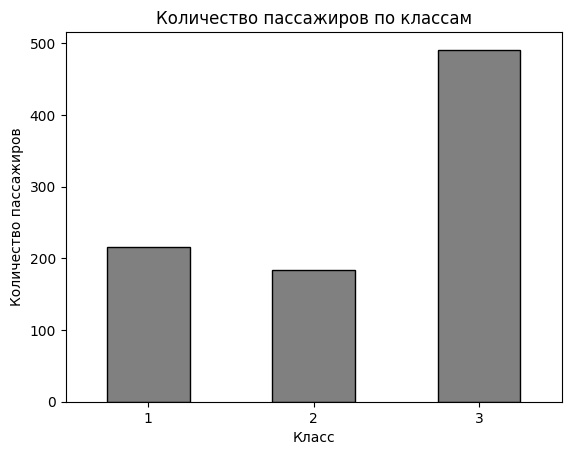

In [65]:
df['Pclass'].value_counts().sort_index().plot(
    kind='bar', color='grey', edgecolor='black')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.show()

Построила график кол-ва пассажиров по классам

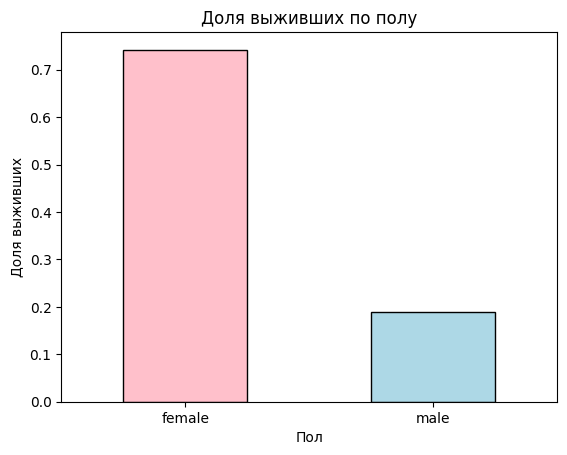

In [69]:
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', color=['pink', 'lightblue'], edgecolor='black')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()

Построила график выживаемости по полу

**Мой вопрос: влияет ли класс на выживаемость среди женщин?**

In [76]:
women = df[df['Sex'] == 'female']
print("Выживаемость женщин по классам:")
print(women.groupby('Pclass')['Survived'].mean().round(3))

Выживаемость женщин по классам:
Pclass
1    0.968
2    0.921
3    0.500
Name: Survived, dtype: float64


Класс сильно влияет на выживаемость среди женщин. Женщины 1 класса выживали в 96.8% случаев, 2 класса — в 92.1%, а вот женщины 3 класса — только в 50%